
## Heart Disease Prediction Using Machine Learning

Methodology Workflow:

1. Dataset loading and description  
2. Data cleaning and preprocessing  
3. Feature selection  
4. Imbalanced data handling using SMOTE  
5. Classification using three models:
   - XGBoost
   - LightGBM
   - Artificial Neural Network (ANN)
6. Hyperparameter optimization  
7. Evaluation using Accuracy, Precision, Recall, F1-score, and Confusion Matrix  
8. Feature importance / explainability support

## 1. Import Libraries



In [ ]:
# Optional installation cell for Google Colab / Jupyter environments.
# Uncomment and run if any package is missing.
# !pip install xgboost lightgbm imbalanced-learn

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
DATA_PATH = "heart.csv"

os.makedirs("results", exist_ok=True)

## 2. Load Dataset



In [ ]:
df_original = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df_original.shape)
print("\nFirst five rows:")
display(df_original.head())

print("\nDataset columns:")
print(df_original.columns.tolist())

Original dataset shape: (1025, 14)

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Dataset columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


## 3. Dataset Description and Initial Checking

The target column is `target`.

- `target = 1`: patient has heart disease  
- `target = 0`: patient does not have heart disease

In [ ]:
print("Dataset information:")
display(df_original.info())

print("\nMissing values per column:")
display(df_original.isnull().sum())

print("\nNumber of duplicate rows:", df_original.duplicated().sum())

print("\nClass distribution before duplicate removal:")
display(df_original["target"].value_counts().rename_axis("Class").reset_index(name="Count"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None


Missing values per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Number of duplicate rows: 723

Class distribution before duplicate removal:


,Class,Count
0,1,526
1,0,499


## 4. Data Cleaning



In [ ]:
df = df_original.drop_duplicates().reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Missing values after cleaning:", df.isnull().sum().sum())

class_counts = df["target"].value_counts().sort_index()
display(class_counts.rename_axis("Class").reset_index(name="Count"))

Cleaned dataset shape: (302, 14)
Duplicate rows after cleaning: 0
Missing values after cleaning: 0


,Class,Count
0,0,138
1,1,164


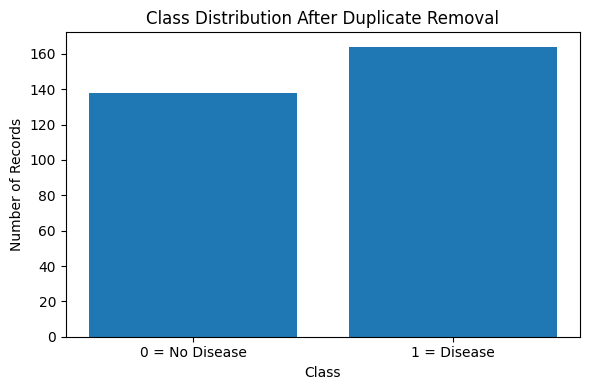

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["0 = No Disease", "1 = Disease"])
plt.tight_layout()
plt.savefig("results/class_distribution.png", dpi=300)
plt.show()

## 5. Exploratory Data Analysis



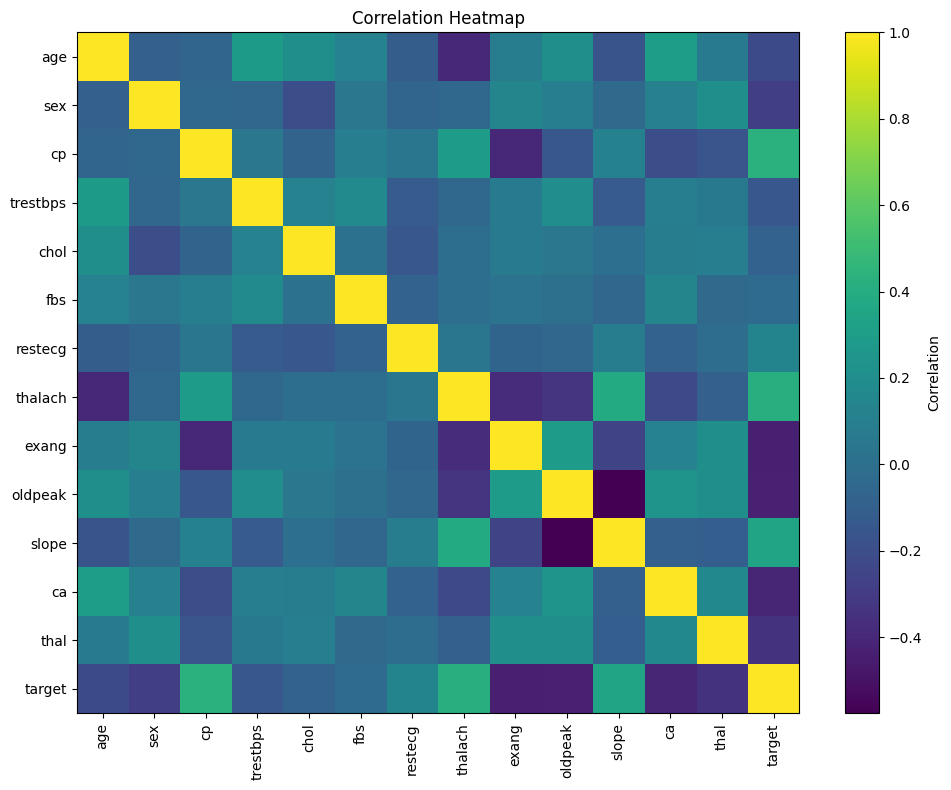

Correlation with target:


,Feature,Correlation_with_Target
0,exang,-0.435601
1,cp,0.432080
2,oldpeak,-0.429146
3,thalach,0.419955
4,ca,-0.408992
5,slope,0.343940
6,thal,-0.343101
7,sex,-0.283609
8,age,-0.221476
9,trestbps,-0.146269


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("results/correlation_heatmap.png", dpi=300)
plt.show()

target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("Correlation with target:")
display(target_corr.reset_index().rename(columns={"index": "Feature", "target": "Correlation_with_Target"}))

## 6. Split Features and Target



In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
display(y_test.value_counts().sort_index())

X_train shape: (241, 13)
X_test shape: (61, 13)

Training class distribution:


,count
target,
0,110
1,131



Testing class distribution:


,count
target,
0,28
1,33


## 7. Preprocessing



In [ ]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
128,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
158,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
265,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
262,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
136,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643


## 8. Feature Selection



In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_train_scaled, y_train)

selected_features = X.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information_Score": selector.scores_
}).sort_values("Mutual_Information_Score", ascending=False)

print("Selected features:")
print(selected_features)

display(feature_scores)

feature_scores.to_csv("results/feature_selection_scores.csv", index=False)

Selected features:
['sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,Feature,Mutual_Information_Score
11,ca,0.160255
2,cp,0.138604
12,thal,0.101749
10,slope,0.098327
8,exang,0.082885
9,oldpeak,0.065479
7,thalach,0.055056
4,chol,0.042898
3,trestbps,0.029238
1,sex,0.022468


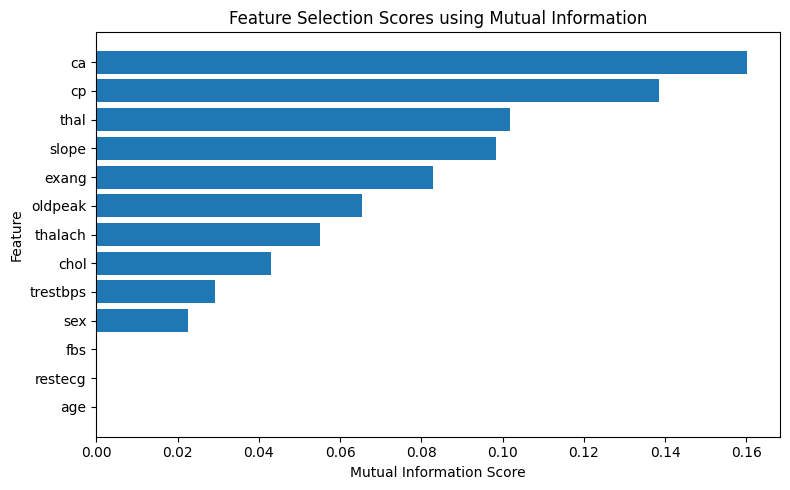

In [ ]:
plt.figure(figsize=(8, 5))
scores_plot = feature_scores.sort_values("Mutual_Information_Score", ascending=True)
plt.barh(scores_plot["Feature"], scores_plot["Mutual_Information_Score"])
plt.title("Feature Selection Scores using Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("results/feature_selection_scores.png", dpi=300)
plt.show()

In [ ]:
X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print("Training data after feature selection:", X_train_selected.shape)
print("Testing data after feature selection:", X_test_selected.shape)

Training data after feature selection: (241, 10)
Testing data after feature selection: (61, 10)


## 9. Imbalanced Data Handling using SMOTE



In [ ]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("Before SMOTE:")
display(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
display(pd.Series(y_train_smote).value_counts().sort_index())

Before SMOTE:


,count
target,
0,110
1,131



After SMOTE:


,count
target,
0,131
1,131


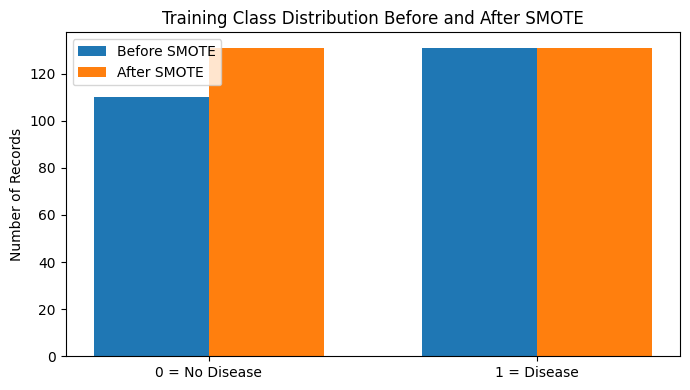

In [ ]:
before_counts = y_train.value_counts().sort_index()
after_counts = pd.Series(y_train_smote).value_counts().sort_index()

plt.figure(figsize=(7, 4))
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, before_counts.values, width, label="Before SMOTE")
plt.bar(x + width/2, after_counts.values, width, label="After SMOTE")
plt.xticks(x, ["0 = No Disease", "1 = Disease"])
plt.ylabel("Number of Records")
plt.title("Training Class Distribution Before and After SMOTE")
plt.legend()
plt.tight_layout()
plt.savefig("results/smote_distribution.png", dpi=300)
plt.show()

## 10. Helper Function for Model Evaluation

The evaluation function reports:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- False Negatives



In [ ]:
def evaluate_model(model, model_name, X_test, y_test, save_prefix):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(f"results/{save_prefix}_confusion_matrix.png", dpi=300)
    plt.show()

    # ROC curve if predict_proba is available.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(f"results/{save_prefix}_roc_curve.png", dpi=300)
        plt.show()

        metrics["AUC"] = roc_auc
    else:
        metrics["AUC"] = np.nan

    return metrics

## 11. Baseline Model Training




XGBoost Baseline
----------------
Confusion Matrix:
[[21  7]
 [10 23]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6774    0.7500    0.7119        28
           1     0.7667    0.6970    0.7302        33

    accuracy                         0.7213        61
   macro avg     0.7220    0.7235    0.7210        61
weighted avg     0.7257    0.7213    0.7218        61



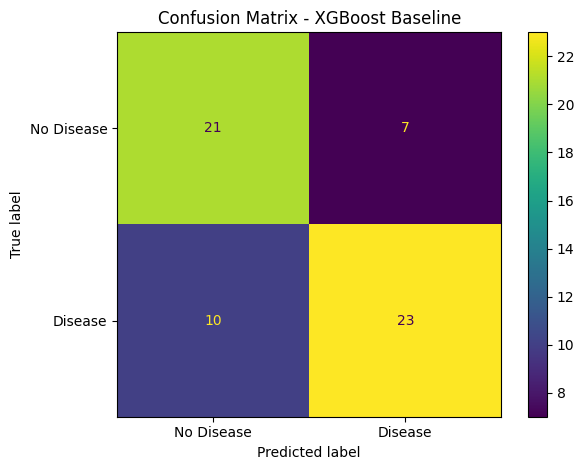

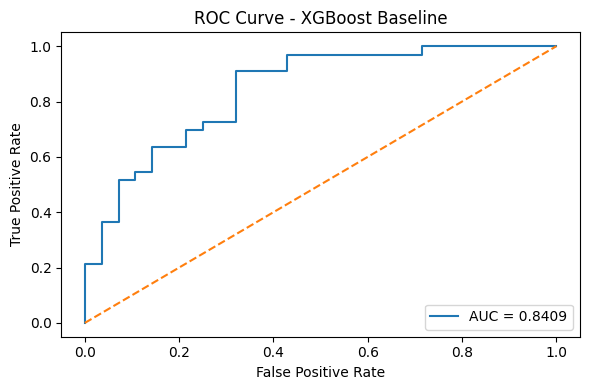


LightGBM Baseline
-----------------
Confusion Matrix:
[[22  6]
 [11 22]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6667    0.7857    0.7213        28
           1     0.7857    0.6667    0.7213        33

    accuracy                         0.7213        61
   macro avg     0.7262    0.7262    0.7213        61
weighted avg     0.7311    0.7213    0.7213        61



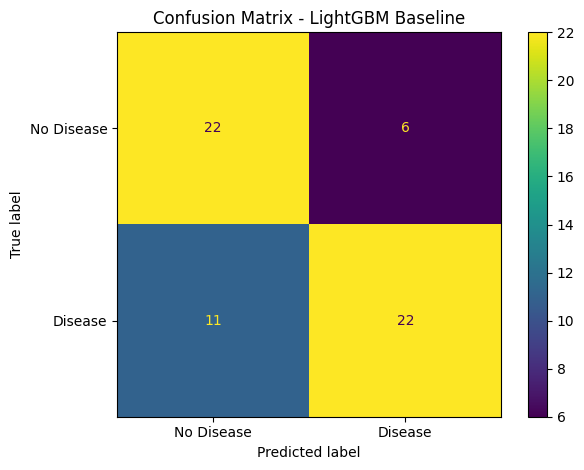

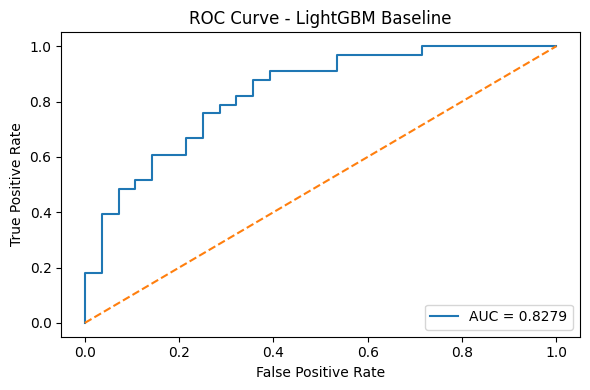


ANN Baseline
------------
Confusion Matrix:
[[20  8]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7407    0.7143    0.7273        28
           1     0.7647    0.7879    0.7761        33

    accuracy                         0.7541        61
   macro avg     0.7527    0.7511    0.7517        61
weighted avg     0.7537    0.7541    0.7537        61



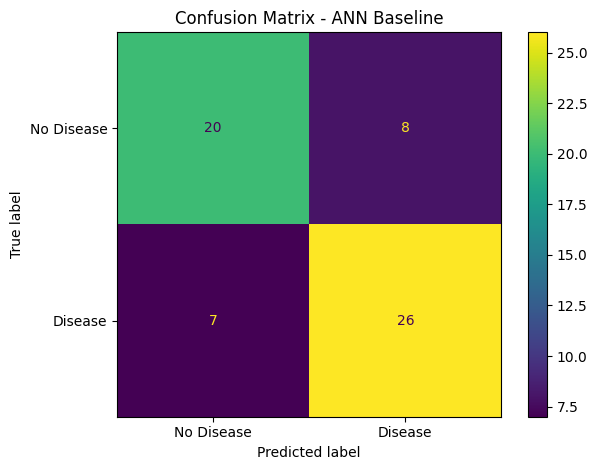

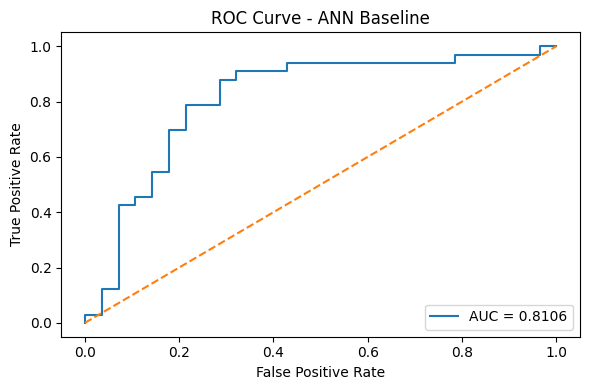

,Model,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP,AUC,Training Time (seconds)
0,XGBoost Baseline,0.721311,0.766667,0.696970,0.730159,21,7,10,23,0.840909,0.256194
1,LightGBM Baseline,0.721311,0.785714,0.666667,0.721311,22,6,11,22,0.827922,0.134539
2,ANN Baseline,0.754098,0.764706,0.787879,0.776119,20,8,7,26,0.810606,1.454738


In [ ]:
baseline_models = {
    "XGBoost Baseline": XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "LightGBM Baseline": LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1
    ),
    "ANN Baseline": MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        max_iter=2000,
        random_state=RANDOM_STATE
    )
}

baseline_results = []

for name, model in baseline_models.items():
    start_time = time.time()
    model.fit(X_train_smote, y_train_smote)
    elapsed = time.time() - start_time

    result = evaluate_model(
        model=model,
        model_name=name,
        X_test=X_test_selected,
        y_test=y_test,
        save_prefix=name.lower().replace(" ", "_")
    )
    result["Training Time (seconds)"] = elapsed
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

baseline_results_df.to_csv("results/baseline_model_results.csv", index=False)

## 12. Hyperparameter Optimization



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [2, 3],
            "learning_rate": [0.05, 0.10],
            "subsample": [0.8, 1.0]
        }
    ),
    "LightGBM": (
        LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
        {
            "n_estimators": [50, 100, 200],
            "num_leaves": [7, 15],
            "learning_rate": [0.05, 0.10],
            "max_depth": [3, 5, -1]
        }
    ),
    "Artificial Neural Network": (
        MLPClassifier(random_state=RANDOM_STATE, max_iter=2000),
        {
            "hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
            "activation": ["relu", "tanh"],
            "alpha": [0.0001, 0.001],
            "learning_rate_init": [0.001]
        }
    )
}


Optimizing: XGBoost
Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation recall: 0.8849002849002849

XGBoost
-------
Confusion Matrix:
[[22  6]
 [ 5 28]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8148    0.7857    0.8000        28
           1     0.8235    0.8485    0.8358        33

    accuracy                         0.8197        61
   macro avg     0.8192    0.8171    0.8179        61
weighted avg     0.8195    0.8197    0.8194        61



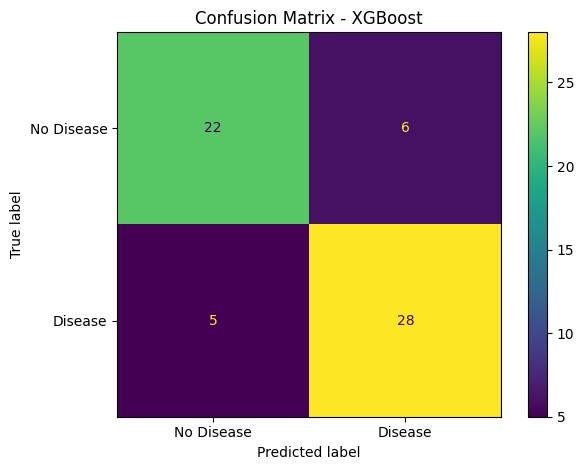

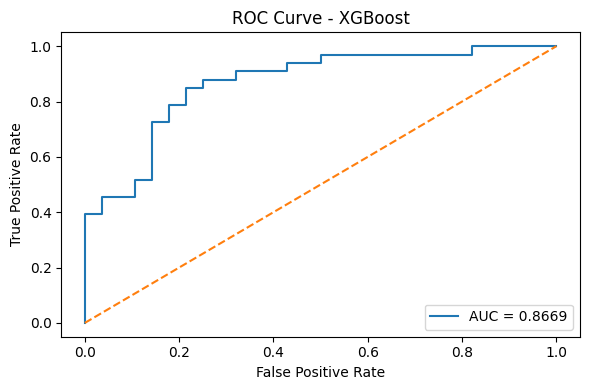


Optimizing: LightGBM
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 15}
Best cross-validation recall: 0.8467236467236468

LightGBM
--------
Confusion Matrix:
[[21  7]
 [ 6 27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7778    0.7500    0.7636        28
           1     0.7941    0.8182    0.8060        33

    accuracy                         0.7869        61
   macro avg     0.7859    0.7841    0.7848        61
weighted avg     0.7866    0.7869    0.7865        61



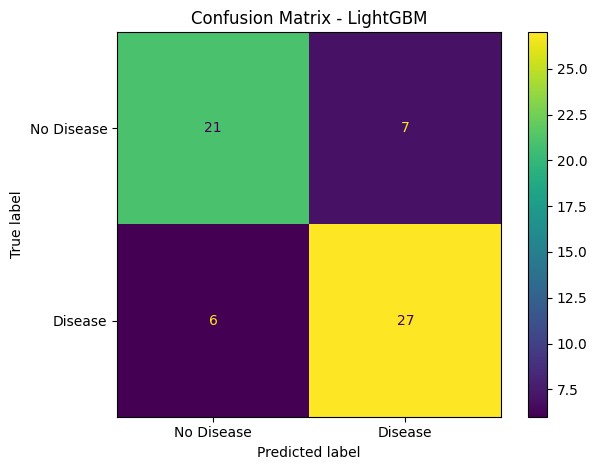

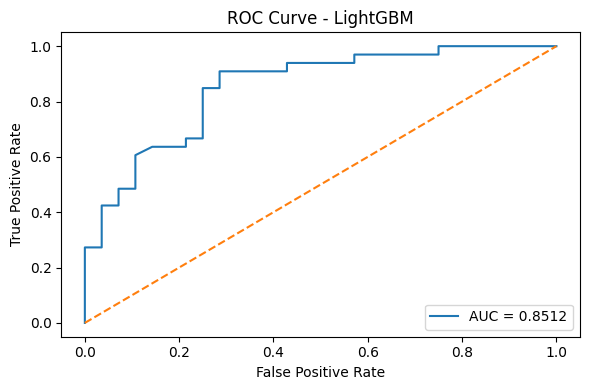


Optimizing: Artificial Neural Network
Best parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}
Best cross-validation recall: 0.892877492877493

Artificial Neural Network
-------------------------
Confusion Matrix:
[[24  4]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7742    0.8571    0.8136        28
           1     0.8667    0.7879    0.8254        33

    accuracy                         0.8197        61
   macro avg     0.8204    0.8225    0.8195        61
weighted avg     0.8242    0.8197    0.8200        61



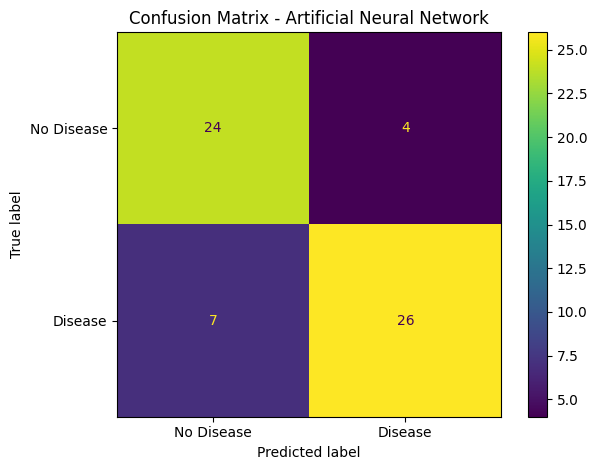

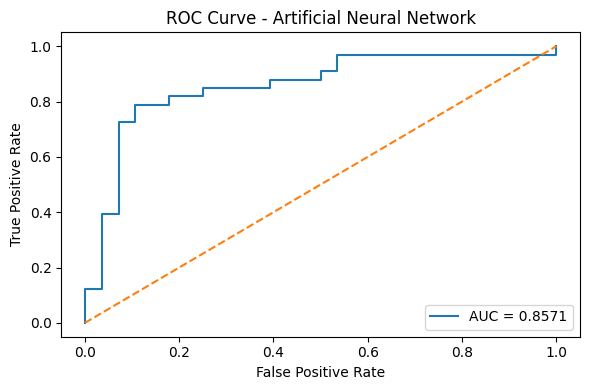

,Model,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP,AUC,Best CV Recall,Training/Tuning Time (seconds)
0,XGBoost,0.819672,0.823529,0.848485,0.835821,22,6,5,28,0.866883,0.884900,6.974151
1,LightGBM,0.786885,0.794118,0.818182,0.805970,21,7,6,27,0.851190,0.846724,4.979424
2,Artificial Neural Network,0.819672,0.866667,0.787879,0.825397,24,4,7,26,0.857143,0.892877,67.875530


In [ ]:
optimized_results = []
best_models = {}
best_parameters = {}

for model_name, (model, param_grid) in model_grids.items():
    print("\nOptimizing:", model_name)

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="recall",
        cv=cv,
        n_jobs=1
    )

    grid_search.fit(X_train_smote, y_train_smote)
    elapsed = time.time() - start_time

    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    best_parameters[model_name] = grid_search.best_params_

    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation recall:", grid_search.best_score_)

    result = evaluate_model(
        model=best_model,
        model_name=model_name,
        X_test=X_test_selected,
        y_test=y_test,
        save_prefix=model_name.lower().replace(" ", "_")
    )

    result["Best CV Recall"] = grid_search.best_score_
    result["Training/Tuning Time (seconds)"] = elapsed
    optimized_results.append(result)

optimized_results_df = pd.DataFrame(optimized_results)
display(optimized_results_df)

optimized_results_df.to_csv("results/optimized_model_results.csv", index=False)

with open("results/best_parameters.txt", "w") as file:
    for model_name, params in best_parameters.items():
        file.write(f"{model_name}: {params}\n")

## 13. Final Model Comparison



In [ ]:
comparison_df = optimized_results_df.sort_values(
    by=["Recall", "F1-score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model based on recall:", best_model_name)

comparison_df.to_csv("results/final_model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP,AUC,Best CV Recall,Training/Tuning Time (seconds)
0,XGBoost,0.819672,0.823529,0.848485,0.835821,22,6,5,28,0.866883,0.884900,6.974151
1,LightGBM,0.786885,0.794118,0.818182,0.805970,21,7,6,27,0.851190,0.846724,4.979424
2,Artificial Neural Network,0.819672,0.866667,0.787879,0.825397,24,4,7,26,0.857143,0.892877,67.875530


Best model based on recall: XGBoost


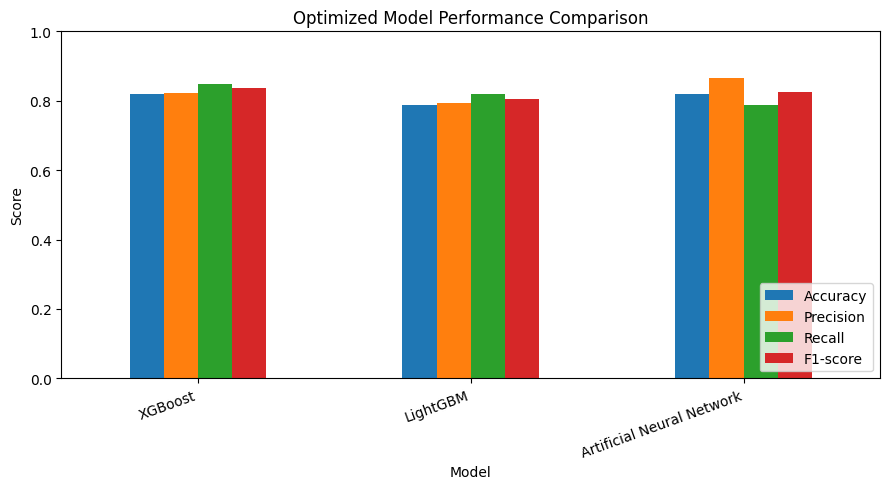

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

plot_df = optimized_results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Optimized Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/optimized_model_comparison.png", dpi=300)
plt.show()

## 14. Feature Importance / Explainability Support



Feature importance for XGBoost:


,Feature,Importance
1,cp,0.213518
9,thal,0.176653
7,slope,0.136973
8,ca,0.090373
4,thalach,0.084091
6,oldpeak,0.077572
5,exang,0.076551
3,chol,0.058754
0,sex,0.047057
2,trestbps,0.038458


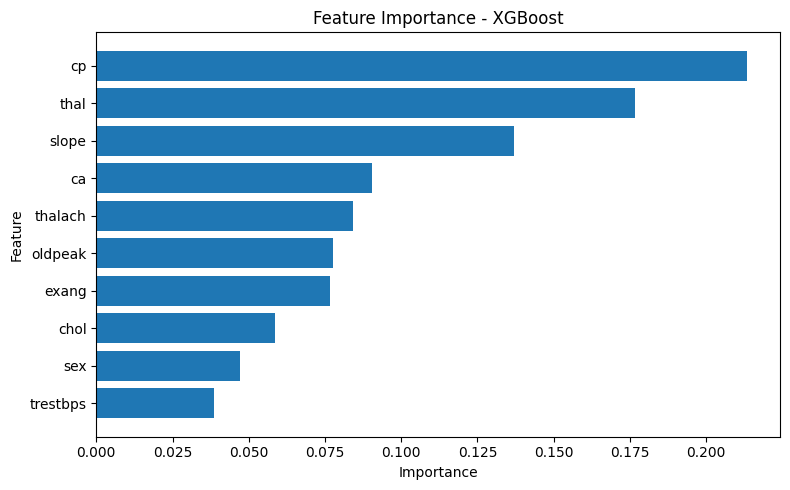


Feature importance for LightGBM:


,Feature,Importance
6,oldpeak,77
4,thalach,74
8,ca,72
3,chol,63
1,cp,61
9,thal,28
0,sex,27
5,exang,19
2,trestbps,14
7,slope,14


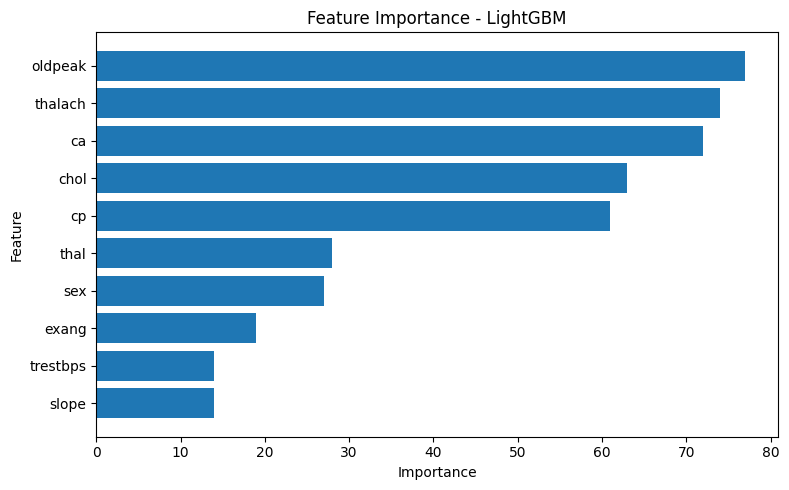

In [ ]:
for model_name in ["XGBoost", "LightGBM"]:
    model = best_models.get(model_name)

    if model is not None and hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": selected_features,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print(f"\nFeature importance for {model_name}:")
        display(importance_df)

        importance_df.to_csv(f"results/{model_name.lower()}_feature_importance.csv", index=False)

        plot_data = importance_df.sort_values("Importance", ascending=True)
        plt.figure(figsize=(8, 5))
        plt.barh(plot_data["Feature"], plot_data["Importance"])
        plt.title(f"Feature Importance - {model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(f"results/{model_name.lower()}_feature_importance.png", dpi=300)
        plt.show()

## 15. Saved Output Files


In [ ]:
print("Saved files in results folder:")
for file in sorted(os.listdir("results")):
    print("-", file)

Saved files in results folder:
- ann_baseline_confusion_matrix.png
- ann_baseline_roc_curve.png
- artificial_neural_network_confusion_matrix.png
- artificial_neural_network_roc_curve.png
- baseline_model_results.csv
- best_parameters.txt
- class_distribution.png
- correlation_heatmap.png
- feature_selection_scores.csv
- feature_selection_scores.png
- final_model_comparison.csv
- lightgbm_baseline_confusion_matrix.png
- lightgbm_baseline_roc_curve.png
- lightgbm_confusion_matrix.png
- lightgbm_feature_importance.csv
- lightgbm_feature_importance.png
- lightgbm_roc_curve.png
- optimized_model_comparison.png
- optimized_model_results.csv
- smote_distribution.png
- xgboost_baseline_confusion_matrix.png
- xgboost_baseline_roc_curve.png
- xgboost_confusion_matrix.png
- xgboost_feature_importance.csv
- xgboost_feature_importance.png
- xgboost_roc_curve.png
